In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 391606 entries, 0 to 391605
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   image_path              391606 non-null  str  
 1   image_filename          391606 non-null  str  
 2   image_id                391606 non-null  str  
 3   panel_suffix            391606 non-null  str  
 4   visualization_category  391606 non-null  str  
 5   visualization_subtype   391606 non-null  str  
 6   subcaption              391606 non-null  str  
 7   summary                 391606 non-null  str  
 8   domain                  391606 non-null  str  
dtypes: str(9)
memory usage: 247.5 MB


In [4]:
print("\nCategory / Subcategory counts:")
print(df.groupby(["visualization_category", "visualization_subtype"]).size().sort_values(ascending=False))


Category / Subcategory counts:
visualization_category  visualization_subtype     
Microscopy              SEM                           66728
Generic Plot            Line Graph                    34847
Simulation              FEA/FEM Result                22418
Microscopy              Optical Micrograph            20944
Photograph              Sample Photo                  18797
                                                      ...  
other                   Neutron dark-field imaging        1
                        Thermography                      1
                        Thermal Image                     1
                        Schlieren imaging                 1
                        Topographic Map                   1
Length: 255, dtype: int64


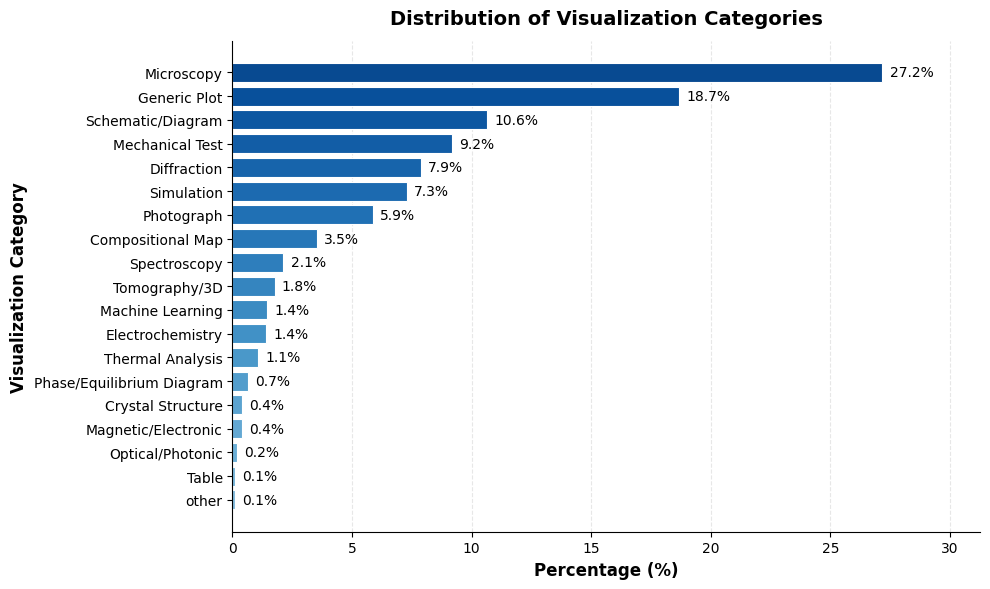

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------
# Category distribution
# -------------------------
counts = (
    df["visualization_category"]
    .value_counts()
    .sort_values(ascending=True)   # ascending for horizontal bars
)

pct = counts / counts.sum() * 100

# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Blues(
    np.linspace(0.45, 0.90, len(counts))
)

bars = ax.barh(
    counts.index,
    pct,
    color=colors,
    edgecolor="white",
    linewidth=0.8
)

# -------------------------
# Percentage labels
# -------------------------
for bar, p in zip(bars, pct):

    ax.text(
        p + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{p:.1f}%",
        va="center",
        fontsize=10
    )

# -------------------------
# Formatting
# -------------------------
ax.set_xlabel(
    "Percentage (%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Visualization Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Distribution of Visualization Categories",
    fontsize=14,
    fontweight="bold",
    pad=12
)

# Clean look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Add some room for labels
ax.set_xlim(0, pct.max() * 1.15)

plt.tight_layout()

# Vector format for paper
plt.savefig(
    "visualization_category_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

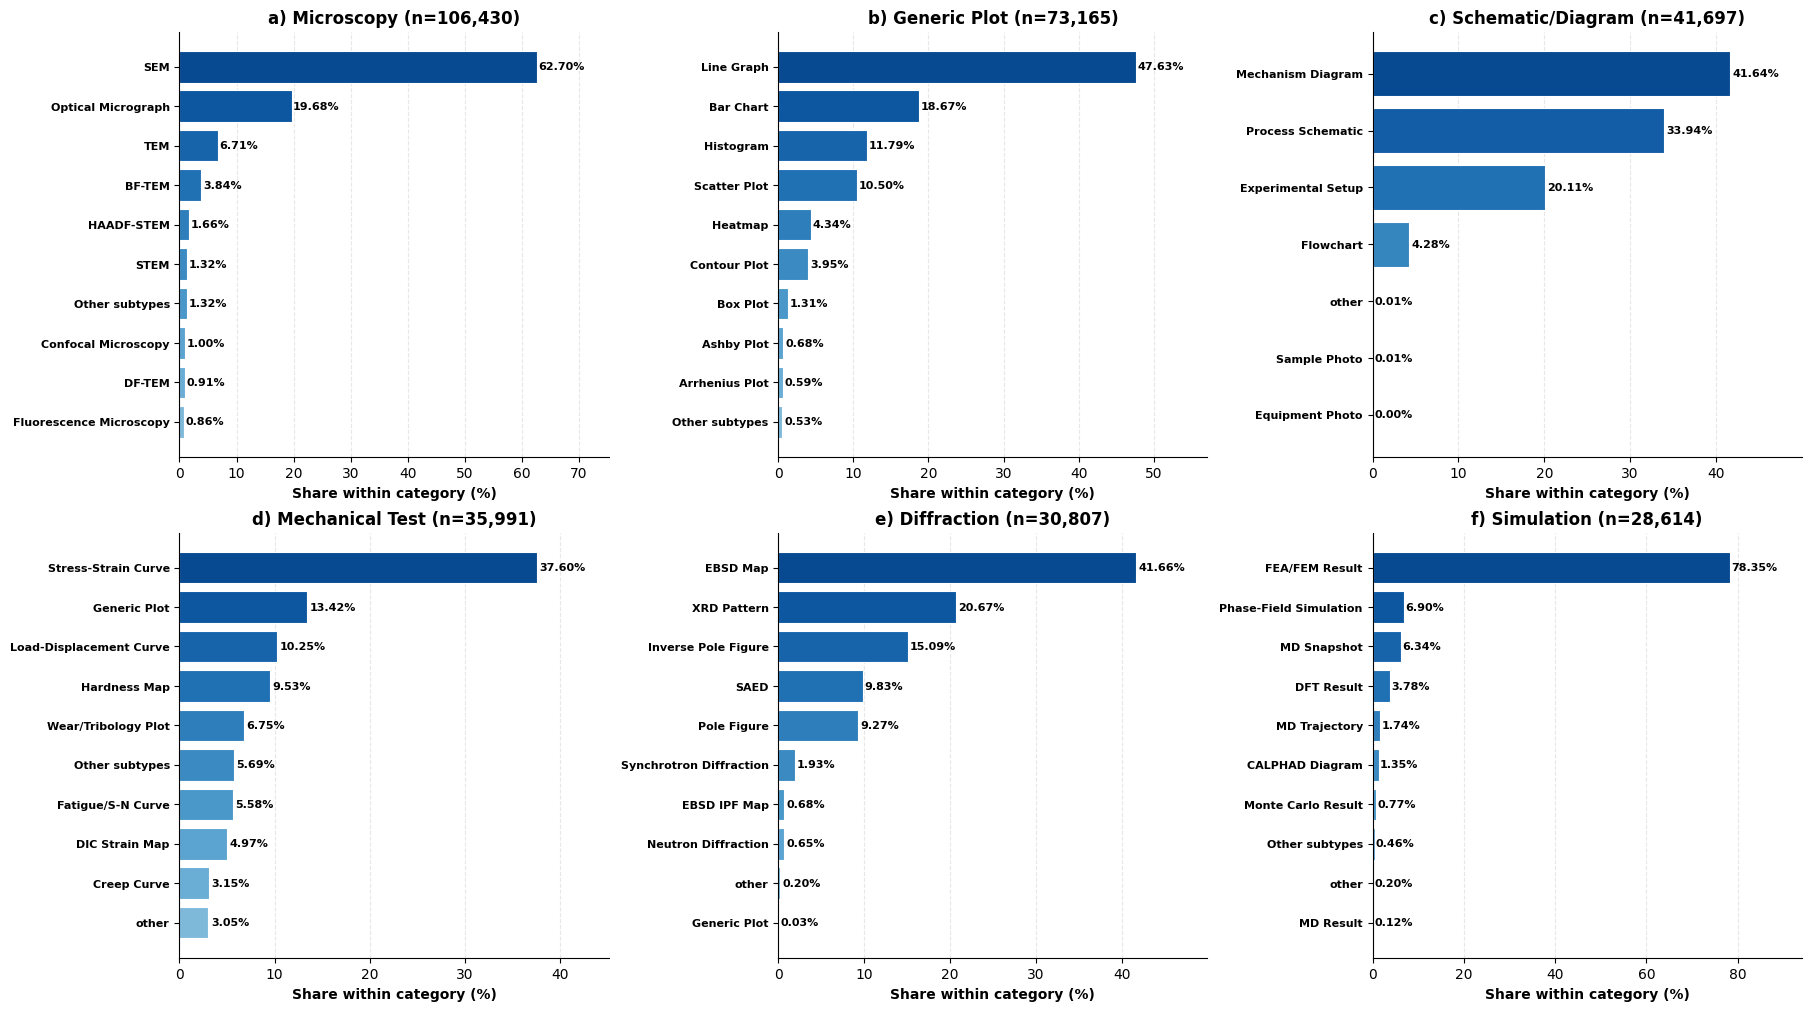

In [28]:
import string 

top6_categories = df["visualization_category"].value_counts().head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

# string.ascii_lowercase gives 'abcdefghijklmnopqrstuvwxyz'
alphabet = string.ascii_lowercase 

for i, cat in enumerate(top6_categories):
    ax = axes[i]
    
    sub_pct = (
        df.loc[df["visualization_category"] == cat, "visualization_subtype"]
        .value_counts(normalize=True)
        * 100
    )
    
    # Keep figure readable for paper: top 9 + "Other subtypes"
    if len(sub_pct) > 10:
        plot_series = pd.concat(
            [sub_pct.head(9), pd.Series({"Other subtypes": sub_pct.iloc[9:].sum()})]
        )
    else:
        plot_series = sub_pct.copy()
    
    plot_series = plot_series.sort_values(ascending=True)
    colors = plt.cm.Blues(np.linspace(0.45, 0.9, len(plot_series)))
    
    bars = ax.barh(
        plot_series.index,
        plot_series.values,
        color=colors,
        edgecolor="white",
        linewidth=0.8
    )
    
    for b, v in zip(bars, plot_series.values):
        if v >= 0.0:
            ax.text(v + 0.25, b.get_y() + b.get_height() / 2, f"{v:.2f}%", va="center", fontsize=8, fontweight="bold")
    
    n_cat = (df["visualization_category"] == cat).sum()
    
    # --- UPDATED LINE HERE ---
    # alphabet[i] pulls 'a' for 0, 'b' for 1, etc.
    ax.set_title(f"{alphabet[i]}) {cat} (n={n_cat:,})", fontsize=12, fontweight="bold")
    
    ax.set_xlabel("Share within category (%)", fontsize=10, fontweight="bold")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)
    plt.setp(ax.get_yticklabels(), fontweight="bold")
    ax.set_xlim(0, plot_series.max() * 1.2)

plt.savefig("top6_categories_subcategories_subplots.pdf", bbox_inches="tight")
# plt.show() # Optional if you just want to save

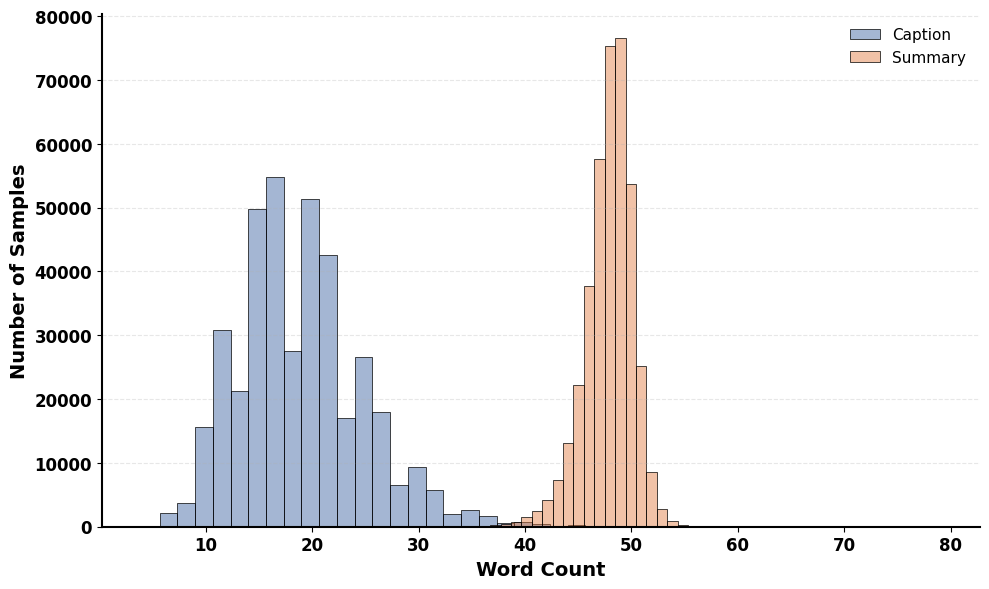

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

caption_wc = (
    df["subcaption"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

summary_wc = (
    df["summary"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

# Nature-style colors
caption_color = "#365E9E"
summary_color = "#E0783C"

sns.histplot(
    caption_wc,
    bins=45,
    stat="count",
    color=caption_color,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.5,
    label="Caption",
    ax=ax
)

sns.histplot(
    summary_wc,
    bins=45,
    stat="count",
    color=summary_color,
    alpha=0.45,
    edgecolor="black",
    linewidth=0.5,
    label="Summary",
    ax=ax
)

# Labels
ax.set_xlabel("Word Count", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Samples", fontsize=14, fontweight="bold")
# Tick styling
ax.tick_params(
    axis="both",
    labelsize=12
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# Legend
legend = ax.legend(
    fontsize=11,
    frameon=False
)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Light grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "word_count_distribution.pdf",
    bbox_inches="tight"
)

plt.show()